# Kinetic Transition Network Analysis

**Hexapeptide Energy Landscapes: Graph-Theoretic & Deep Learning Analysis**

This notebook visualises the results of the GT coarse-graining pipeline,
graph-feature regression, and GNN experiments at T = 300 K.

In [17]:
import pathlib, warnings, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEQ_CLASS_COLOURS = {
    "charged": "#E63946",   # red
    "polar":   "#457B9D",   # steel blue
    "hydrophobic": "#2A9D8F",  # teal
    "mixed":   "#E9C46A",   # gold
    "default": "#264653",   # dark slate
}
ACCENT  = "#E63946"
BLUE    = "#457B9D"
TEAL    = "#2A9D8F"
GOLD    = "#E9C46A"
DARK    = "#264653"
PALETTE = [DARK, ACCENT, BLUE, TEAL, GOLD]

print("Style loaded.")

ml_dir  = pathlib.Path("ml_results_cpu")
gnn_dir = pathlib.Path("gnn_results_v2")


Style loaded.


In [18]:
# ── Helper functions ─────────────────────────────────────────────
def seq_label(dps_dir_str):
    """Extract short sequence label from dps_dir path."""
    return pathlib.Path(dps_dir_str).parent.name

def classify_sequence(seq):
    """Heuristic amino-acid class for colouring."""
    charged = set("DEKRH")
    polar   = set("STNQ")
    hydro   = set("AVILMFWP")
    s = seq.upper().replace("ALA_", "").replace("_", "")
    cats = {("charged" if c in charged else "polar" if c in polar
             else "hydrophobic" if c in hydro else "mixed") for c in s}
    if len(cats) == 1:
        return cats.pop()
    return "mixed"

def annotate_r2(ax, y_true, y_pred, loc="upper left"):
    """Add R² and RMSE annotation to scatter plot."""
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    ax.text(0.05, 0.95, f"$R^2 = {r2:.3f}$\nRMSE = {rmse:.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    return r2

def parity_line(ax):
    """Add y = x dashed line."""
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], "--", color="gray", lw=0.8, zorder=0)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

print("Helpers loaded.")

Helpers loaded.


---
## 1. Load Baseline Data

In [19]:
# ── Load GTcheck CSV (always available) ──────────────────────────
gt = pd.read_csv("GTcheck_micro_vs_coarse_T300K_full.csv")
gt["seq"] = gt["dps_dir"].apply(seq_label)
gt["seq_class"] = gt["seq"].apply(classify_sequence)
gt["colour"] = gt["seq_class"].map(SEQ_CLASS_COLOURS).fillna(DARK)

# derived columns (actual CSV columns: N_coarse, N_micro, MFPT_*)
gt["compression"] = 1 - gt["N_coarse"] / gt["N_micro"]
gt["log_mfpt_ab_micro"] = np.log10(gt["MFPT_micro_AB"].clip(lower=1e-30))
gt["log_mfpt_ab_coarse"] = np.log10(gt["MFPT_coarse_AB"].clip(lower=1e-30))
gt["log_mfpt_ba_micro"] = np.log10(gt["MFPT_micro_BA"].clip(lower=1e-30))
gt["log_mfpt_ba_coarse"] = np.log10(gt["MFPT_coarse_BA"].clip(lower=1e-30))

print(f"Loaded {len(gt)} landscapes.")
gt[["seq", "N_micro", "N_coarse", "compression"]].head(10)

Loaded 43 landscapes.


,seq,N_micro,N_coarse,compression
0,,33399.0,3243.0,0.902901
1,,9940.0,968.0,0.902616
2,,10267.0,997.0,0.902893
3,,29828.0,2832.0,0.905056
4,,35345.0,3408.0,0.903579
5,,35070.0,3357.0,0.904277
6,,39843.0,3895.0,0.902241
7,,33069.0,3169.0,0.904170
8,,11713.0,1128.0,0.903697
9,,66720.0,6392.0,0.904197


---
## 2. Landscape Overview

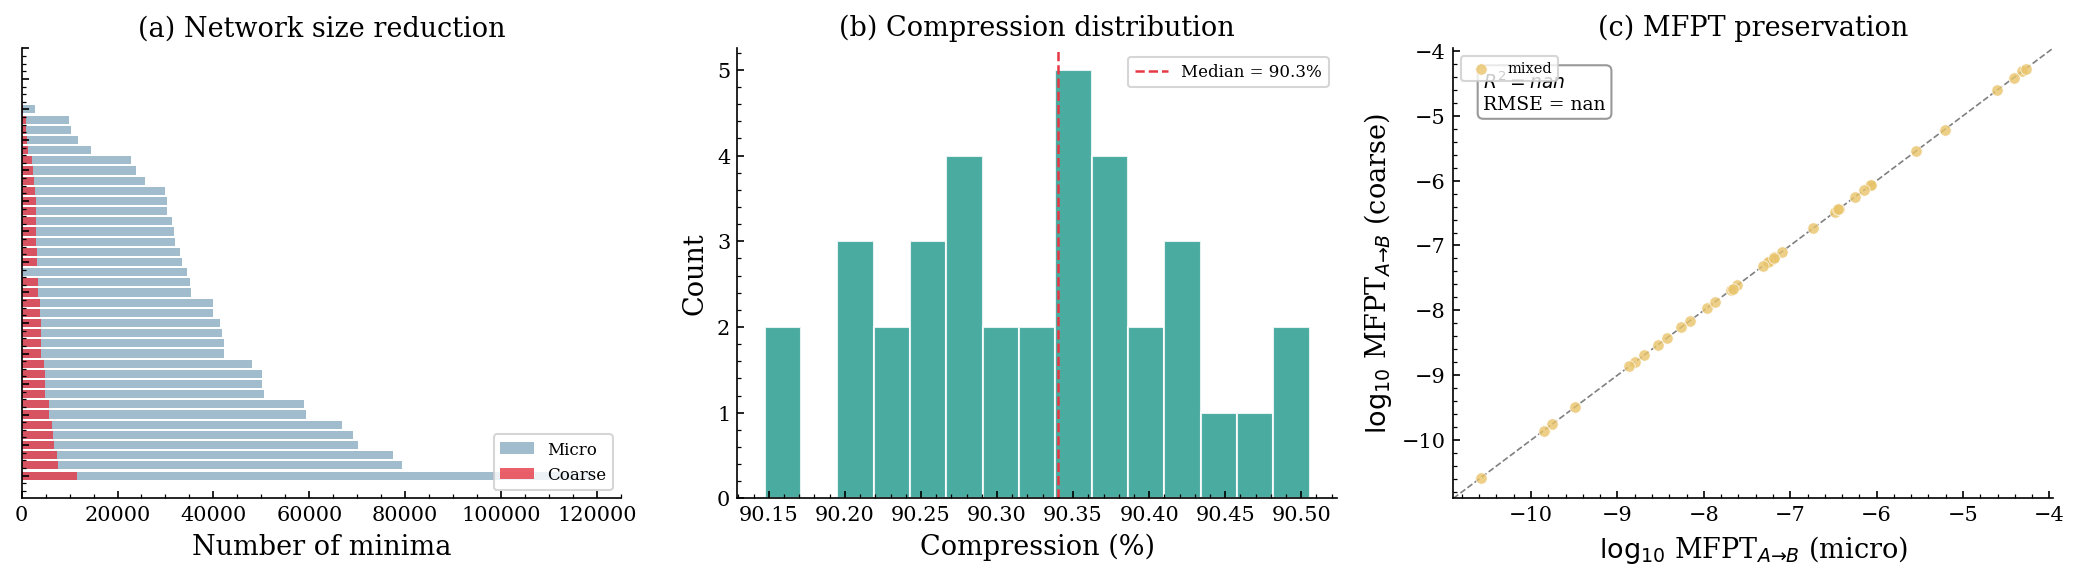

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Size reduction
ax = axes[0]
order = gt.sort_values("N_micro", ascending=False).index
x = np.arange(len(gt))
ax.barh(x, gt.loc[order, "N_micro"], color=BLUE, alpha=0.5, label="Micro")
ax.barh(x, gt.loc[order, "N_coarse"], color=ACCENT, alpha=0.8, label="Coarse")
ax.set_yticks(x[::3])
ax.set_yticklabels(gt.loc[order, "seq"].values[::3], fontsize=7)
ax.set_xlabel("Number of minima")
ax.set_title("(a) Network size reduction")
ax.legend(fontsize=8)

# (b) Compression ratio distribution
ax = axes[1]
ax.hist(gt["compression"] * 100, bins=15, color=TEAL, edgecolor="white", alpha=0.85)
ax.axvline(gt["compression"].median() * 100, color=ACCENT, ls="--", lw=1.2,
           label=f"Median = {gt['compression'].median()*100:.1f}%")
ax.set_xlabel("Compression (%)")
ax.set_ylabel("Count")
ax.set_title("(b) Compression distribution")
ax.legend(fontsize=8)

# (c) MFPT preservation (parity)
ax = axes[2]
for cls, grp in gt.groupby("seq_class"):
    ax.scatter(grp["log_mfpt_ab_micro"], grp["log_mfpt_ab_coarse"],
               c=SEQ_CLASS_COLOURS.get(cls, DARK), label=cls, s=30, alpha=0.8,
               edgecolors="white", linewidths=0.4)
parity_line(ax)
annotate_r2(ax, gt["log_mfpt_ab_micro"].values, gt["log_mfpt_ab_coarse"].values)
ax.set_xlabel(r"$\log_{10}$ MFPT$_{A \to B}$ (micro)")
ax.set_ylabel(r"$\log_{10}$ MFPT$_{A \to B}$ (coarse)")
ax.set_title("(c) MFPT preservation")
ax.legend(fontsize=7, ncol=2)

fig.tight_layout()
fig.savefig("fig_landscape_overview.pdf")
plt.show()

---
## 3. Kinetic Observables

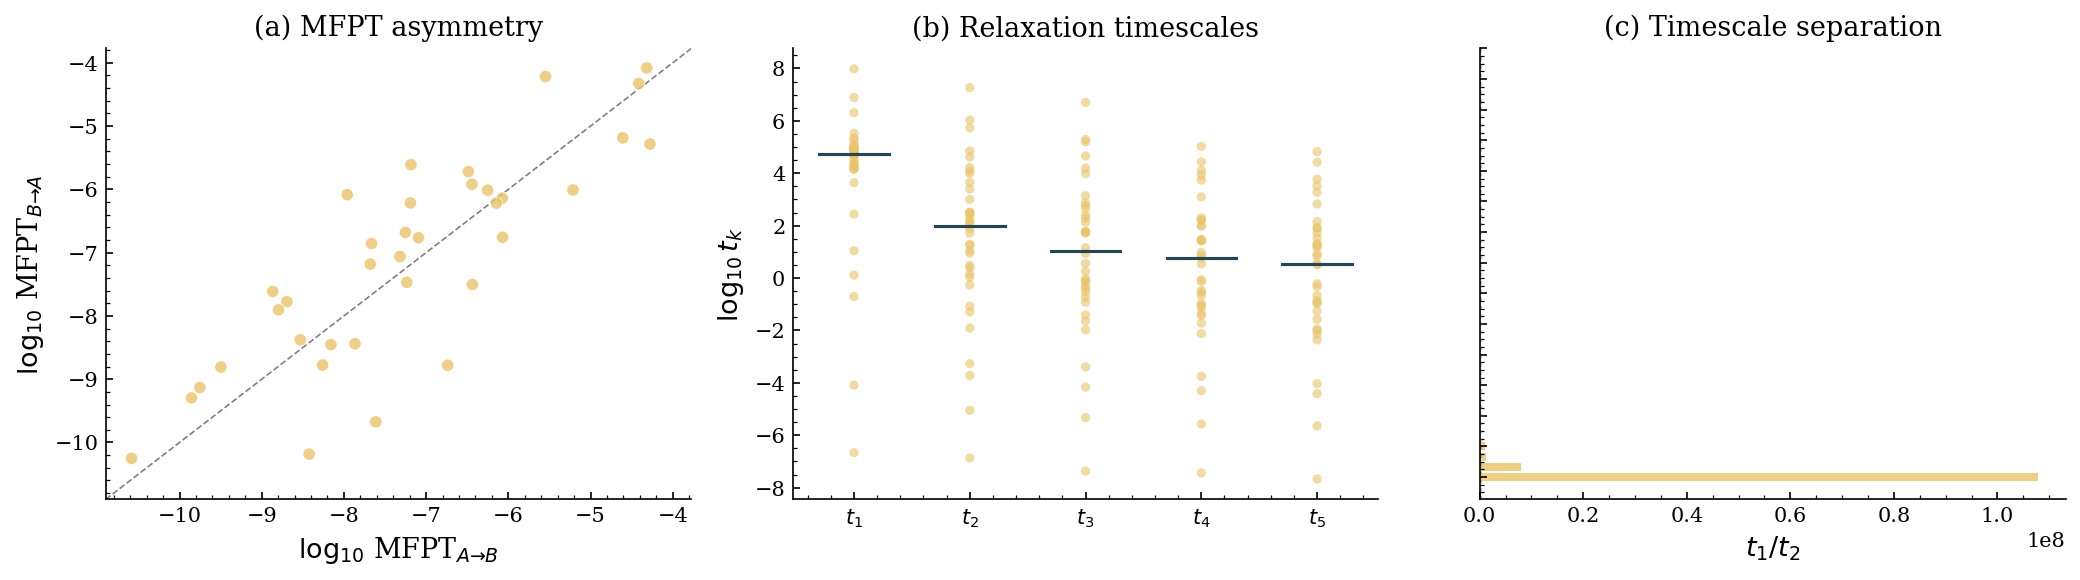

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) MFPT landscape  (AB vs BA)
ax = axes[0]
ax.scatter(gt["log_mfpt_ab_coarse"], gt["log_mfpt_ba_coarse"],
           c=gt["colour"], s=35, alpha=0.8, edgecolors="white", linewidths=0.4)
for _, row in gt.iterrows():
    ax.annotate(row["seq"], (row["log_mfpt_ab_coarse"], row["log_mfpt_ba_coarse"]),
                fontsize=5, alpha=0.6, ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")
parity_line(ax)
ax.set_xlabel(r"$\log_{10}$ MFPT$_{A \to B}$")
ax.set_ylabel(r"$\log_{10}$ MFPT$_{B \to A}$")
ax.set_title("(a) MFPT asymmetry")

# (b) Relaxation timescales
ax = axes[1]
t_cols = [c for c in gt.columns if c.startswith("t") and c[1:].isdigit()]
if len(t_cols) >= 3:
    for i, tc in enumerate(t_cols[:5]):
        vals = np.log10(gt[tc].clip(lower=1e-30))
        ax.scatter(np.full(len(gt), i+1), vals, c=gt["colour"],
                   s=20, alpha=0.6, edgecolors="none")
        ax.plot([i+0.7, i+1.3], [vals.median(), vals.median()],
                color=DARK, lw=1.5)
    ax.set_xticks(range(1, len(t_cols[:5])+1))
    ax.set_xticklabels([f"$t_{{{c[1:]}}}$" for c in t_cols[:5]])
    ax.set_ylabel(r"$\log_{10}\, t_k$")
    ax.set_title("(b) Relaxation timescales")
else:
    ax.text(0.5, 0.5, "Timescale data\nnot available",
            transform=ax.transAxes, ha="center", va="center", fontsize=12)

# (c) Timescale separation (t1/t2)
ax = axes[2]
if "t1" in gt.columns and "t2" in gt.columns:
    ratio = gt["t1"] / gt["t2"]
    order = ratio.sort_values(ascending=False).index
    ax.barh(range(len(gt)), ratio.loc[order], color=gt.loc[order, "colour"], alpha=0.8)
    ax.set_yticks(range(0, len(gt), 3))
    ax.set_yticklabels(gt.loc[order, "seq"].values[::3], fontsize=7)
    ax.set_xlabel("$t_1 / t_2$")
    ax.set_title("(c) Timescale separation")
    ax.axvline(10, ls=":", color="gray", alpha=0.5)
else:
    ax.text(0.5, 0.5, "t1/t2 data\nnot available",
            transform=ax.transAxes, ha="center", va="center", fontsize=12)

fig.tight_layout()
fig.savefig("fig_kinetic_observables.pdf")
plt.show()

---
## 4. Spectral Fingerprints

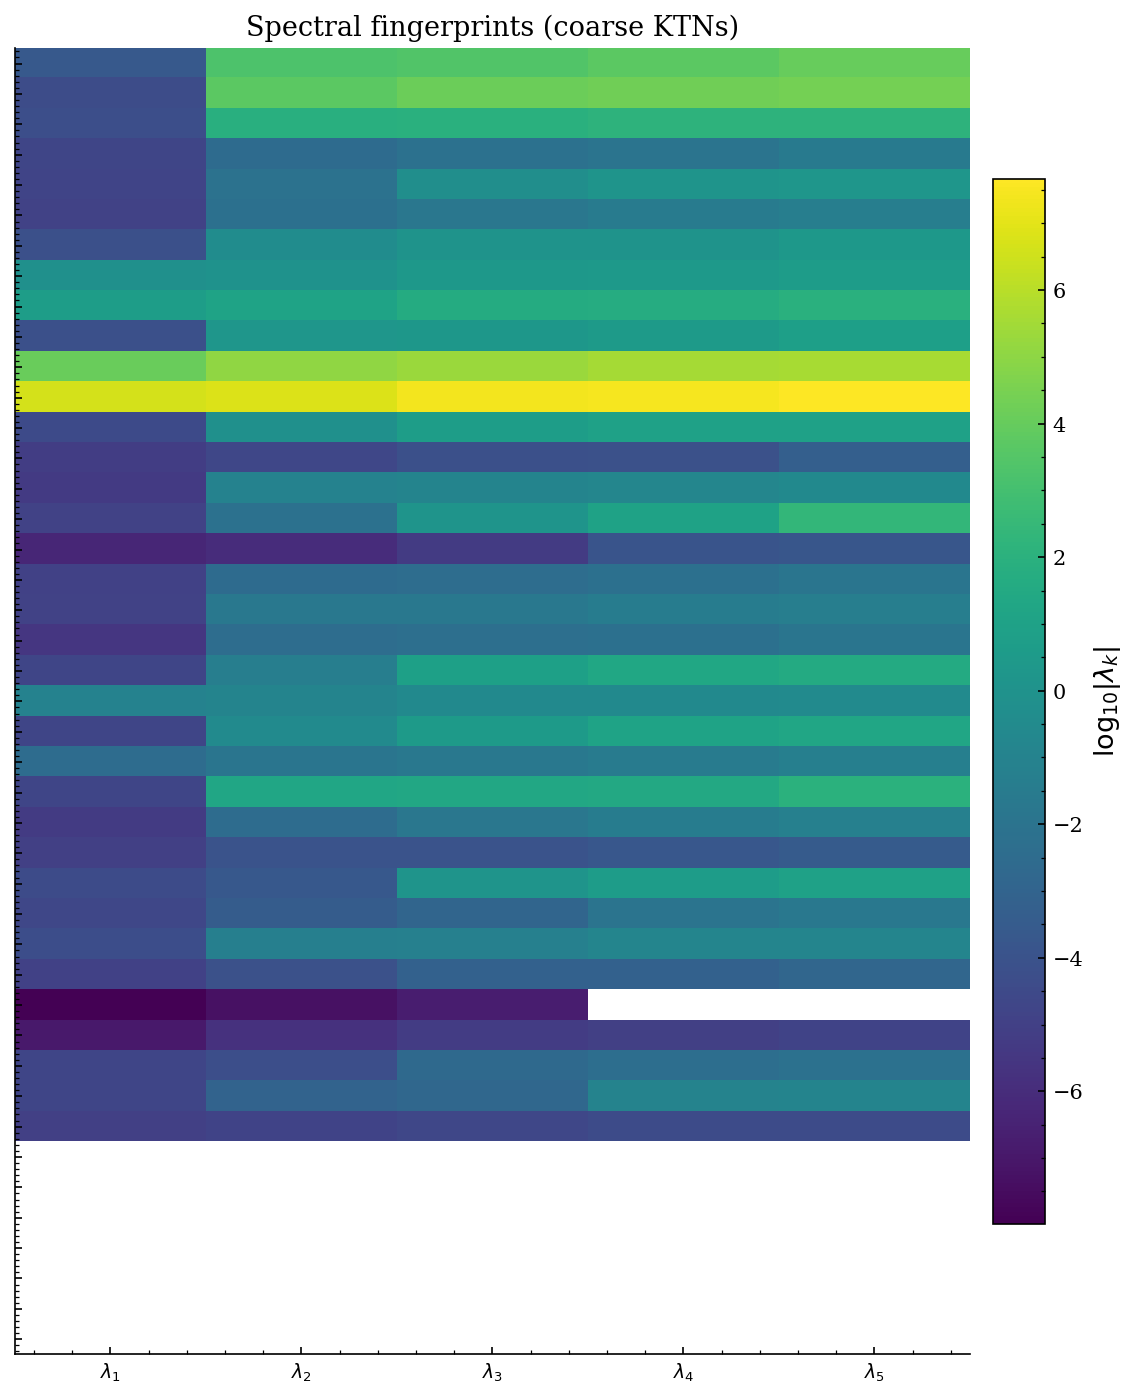

In [22]:
# Heatmap of eigenvalue spectra across landscapes
eig_cols = [c for c in gt.columns if c.startswith("lambda")]
if len(eig_cols) >= 3:
    eig_data = gt[eig_cols].copy()
    eig_data.index = gt["seq"]
    # log-transform (eigenvalues are negative for rate matrices)
    eig_log = np.log10(np.abs(eig_data).clip(lower=1e-30))

    fig, ax = plt.subplots(figsize=(8, max(4, len(gt)*0.22)))
    im = ax.imshow(eig_log.values, aspect="auto", cmap="viridis",
                   interpolation="nearest")
    ax.set_yticks(range(len(gt)))
    ax.set_yticklabels(eig_data.index, fontsize=7)
    ax.set_xticks(range(len(eig_cols)))
    ax.set_xticklabels([f"$\\lambda_{{{c.replace('lambda','')}}}$" for c in eig_cols],
                       fontsize=9)
    ax.set_title("Spectral fingerprints (coarse KTNs)")
    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label(r"$\log_{10}|\lambda_k|$")
    fig.tight_layout()
    fig.savefig("fig_spectral_fingerprints.pdf")
    plt.show()
else:
    print("Eigenvalue columns not found in GTcheck CSV — skipping spectral heatmap.")

---
## 5. Network Topology

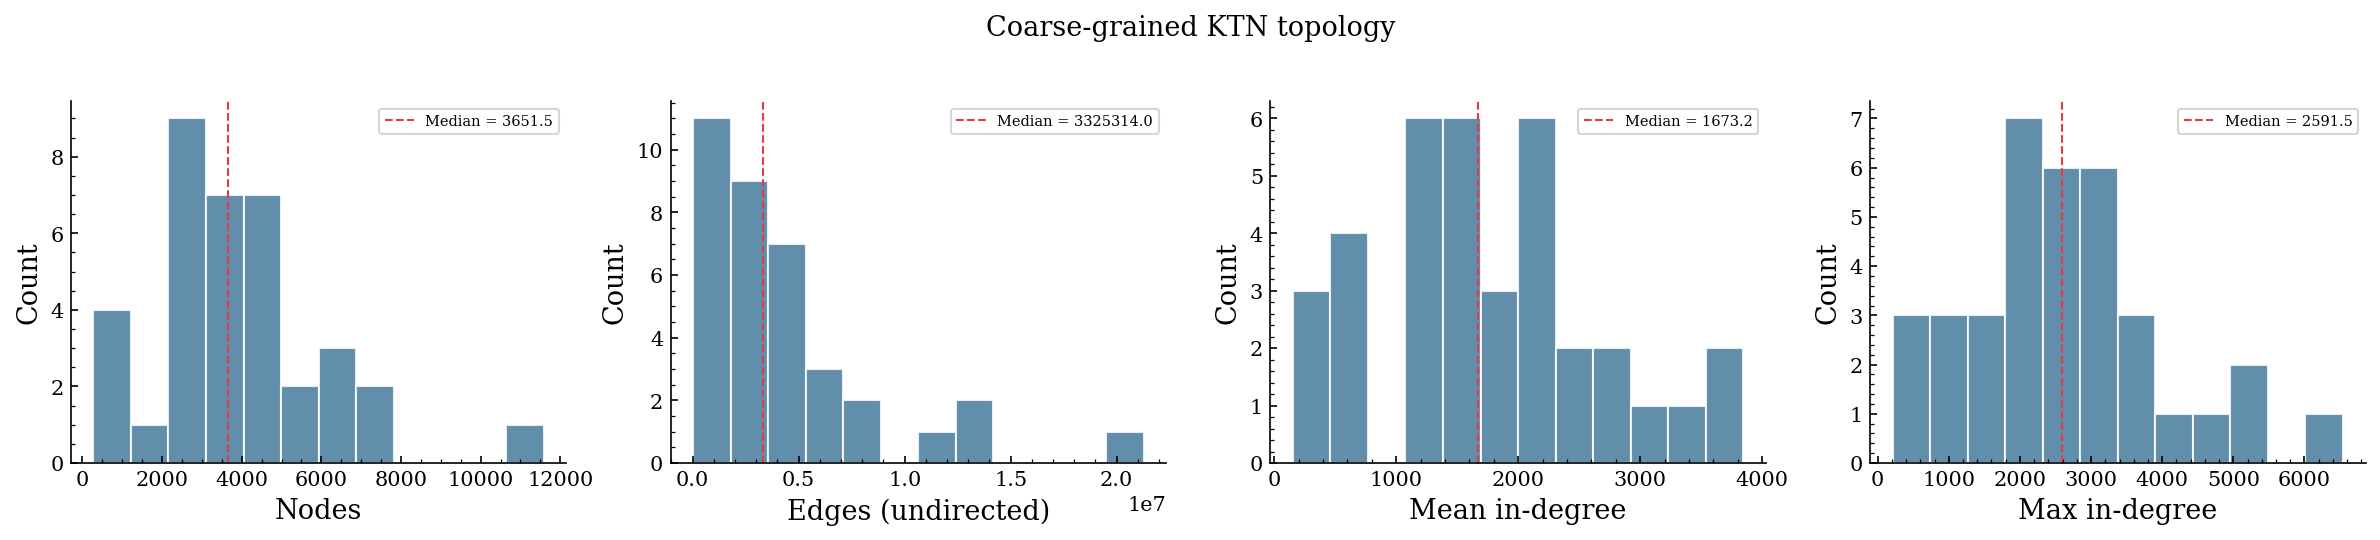

In [23]:
# Map actual GTcheck CSV column names to display labels
topo_cols = {"N_coarse": "Nodes", "edges_undir": "Edges (undirected)",
             "in_deg_mean": "Mean in-degree", "in_deg_max": "Max in-degree"}
avail = {k: v for k, v in topo_cols.items() if k in gt.columns}

if len(avail) >= 2:
    ncols = min(len(avail), 4)
    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 3.5))
    if ncols == 1: axes = [axes]
    for ax, (col, label) in zip(axes, avail.items()):
        ax.hist(gt[col].dropna(), bins=12, color=BLUE, edgecolor="white", alpha=0.85)
        ax.set_xlabel(label)
        ax.set_ylabel("Count")
        med = gt[col].median()
        ax.axvline(med, color=ACCENT, ls="--", lw=1,
                   label=f"Median = {med:.1f}")
        ax.legend(fontsize=7)
    fig.suptitle("Coarse-grained KTN topology", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig("fig_network_topology.pdf")
    plt.show()
else:
    print("Topology columns not found — skipping.")

---
## 6. Graph Features Analysis

Requires `graph_features_coarse_T300K_lite.csv` (produced by `graph_features.py`).

Loaded 43 landscapes x 60 features


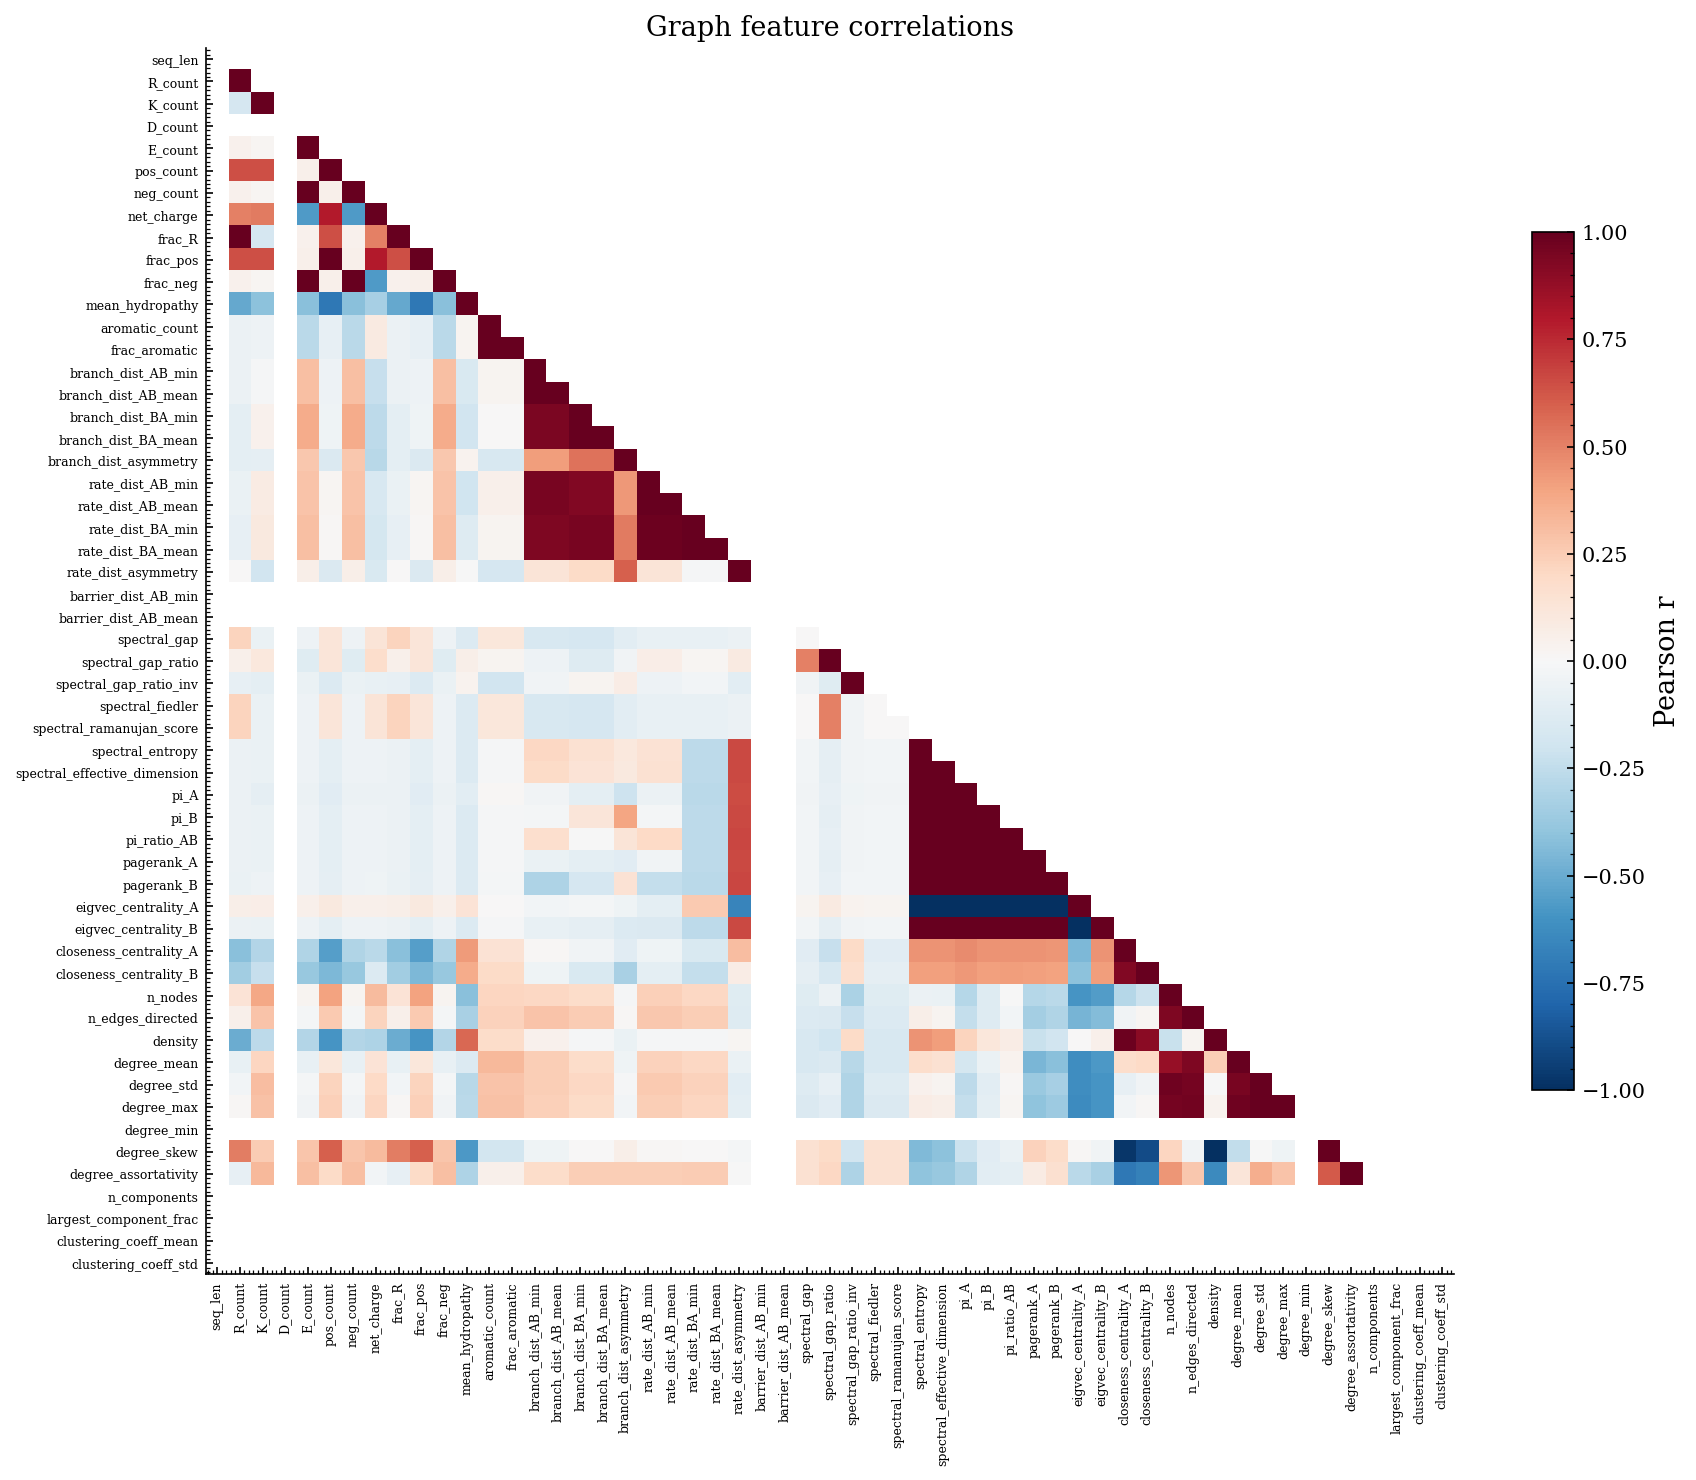

In [24]:
feat_path = pathlib.Path("graph_features_coarse_T300K_lite.csv")
if feat_path.exists():
    feats = pd.read_csv(feat_path)
    # Normalize dps_dir to basename (features CSV may use full paths)
    feats["dps_dir"] = feats["dps_dir"].astype(str).str.rstrip("/").apply(lambda p: pathlib.Path(p).name)
    feats["seq"] = feats["dps_dir"].apply(seq_label)
    print(f"Loaded {len(feats)} landscapes x {feats.shape[1]-2} features")

    # ── Correlation heatmap ──
    num_cols = feats.select_dtypes(include=[np.number]).columns.tolist()
    if "dps_dir" in num_cols: num_cols.remove("dps_dir")
    corr = feats[num_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    im = ax.imshow(corr.where(~mask).values, cmap="RdBu_r", vmin=-1, vmax=1,
                   aspect="auto", interpolation="nearest")
    ax.set_xticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=90, fontsize=6)
    ax.set_yticks(range(len(num_cols)))
    ax.set_yticklabels(num_cols, fontsize=6)
    ax.set_title("Graph feature correlations")
    cb = fig.colorbar(im, ax=ax, shrink=0.7)
    cb.set_label("Pearson r")
    fig.tight_layout()
    fig.savefig("fig_feature_correlations.pdf")
    plt.show()
else:
    print("graph_features_coarse_T300K_lite.csv not found.")
    print("Run: python graph_features.py --T 300 --out graph_features_coarse_T300K_lite.csv")
    feats = None


ValueError: x and y must have length at least 2.

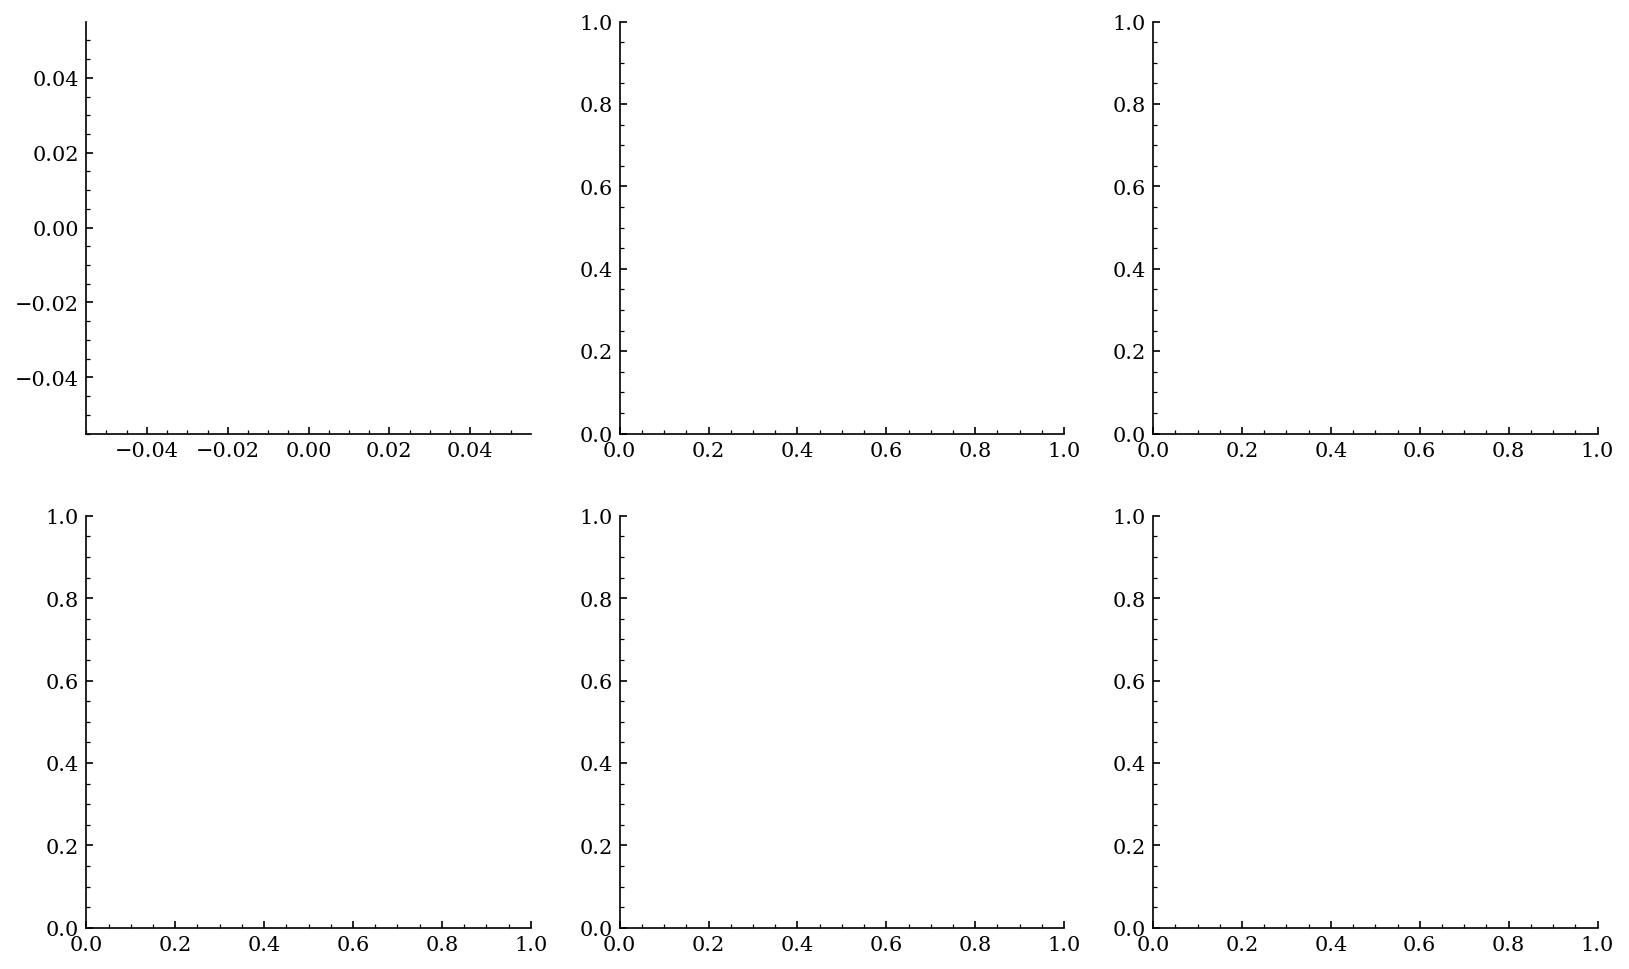

In [25]:
# ── Top feature vs target scatter panels ─────────────────────────
if feats is not None:
    # Merge features with targets (normalize dps_dir to basename for matching)
    gt_merge = gt[["dps_dir", "seq", "colour",
                   "log_mfpt_ab_coarse", "log_mfpt_ba_coarse"]].copy()
    gt_merge["dps_dir"] = gt_merge["dps_dir"].astype(str).str.rstrip("/").apply(
        lambda p: pathlib.Path(p).name)
    merged = feats.merge(gt_merge, on="dps_dir", suffixes=("", "_gt"))
    print(f"Merged: {len(merged)} rows")

    target = "log_mfpt_ab_coarse"
    # Pick top correlated features
    feat_cols = [c for c in num_cols if c not in
                 ["log_mfpt_ab_coarse", "log_mfpt_ba_coarse"]]
    cors = merged[feat_cols].corrwith(merged[target]).abs().sort_values(ascending=False)
    top6 = cors.head(6).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, feat_name in zip(axes.flat, top6):
        ax.scatter(merged[feat_name], merged[target],
                   c=merged["colour"], s=30, alpha=0.8,
                   edgecolors="white", linewidths=0.4)
        mask = merged[[feat_name, target]].dropna().index
        if len(mask) >= 2:
            r, p = stats.pearsonr(merged.loc[mask, feat_name].values, merged.loc[mask, target].values)
        else:
            r, p = float("nan"), float("nan")
        ax.set_xlabel(feat_name.replace("_", " "), fontsize=9)
        ax.set_ylabel(r"$\log_{10}$ MFPT$_{A \to B}$", fontsize=9)
        ax.set_title(f"r = {r:.3f}  (p = {p:.2e})", fontsize=9)
    fig.suptitle("Top 6 features correlated with MFPT$_{A \to B}$",
                 fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig("fig_top_features.pdf")
    plt.show()


---
## 7. ML Regression Results

Requires output from `ml_regression.py` in `ml_results_cpu/`.

In [26]:
if ml_dir.exists():
    # ── Model comparison table ───────────────────────────────────
    # ml_regression.py saves summary.csv (combined) and model_comparison_{target}.csv (per-target)
    summary_path = ml_dir / "summary.csv"
    if not summary_path.exists():
        summary_path = ml_dir / "model_comparison.csv"  # fallback

    if summary_path.exists():
        mc = pd.read_csv(summary_path)
        print("=== Model Comparison (LOO-CV) ===")
        fmt_cols = {c: "{:.4f}" for c in mc.columns if c in ("R2", "RMSE", "MAE")}
        styled = mc.style.format(fmt_cols)
        if "R2" in mc.columns:
            styled = styled.background_gradient(subset=["R2"], cmap="RdYlGn", vmin=-1, vmax=1)
        if "RMSE" in mc.columns:
            styled = styled.background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
        display(styled)
    else:
        # Try per-target model_comparison files
        mc_files = sorted(ml_dir.glob("model_comparison_*.csv"))
        if mc_files:
            mc = pd.concat([pd.read_csv(f).assign(target=f.stem.replace("model_comparison_", ""))
                            for f in mc_files], ignore_index=True)
            print("=== Model Comparison (LOO-CV) ===")
            display(mc.style.format(precision=4))
        else:
            print("No model comparison CSV found in ml_results_cpu/.")
            mc = None
else:
    print("ml_results_cpu/ not found. Run: sbatch run_ml_regression.sbatch")
    mc = None


model_comparison.csv not found in ml_results_cpu/.


<__array_function__ internals>:5: UserWarning: Warning: converting a masked element to nan.
/usr/licensed/anaconda3/2021.11/lib/python3.9/site-packages/numpy/core/_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


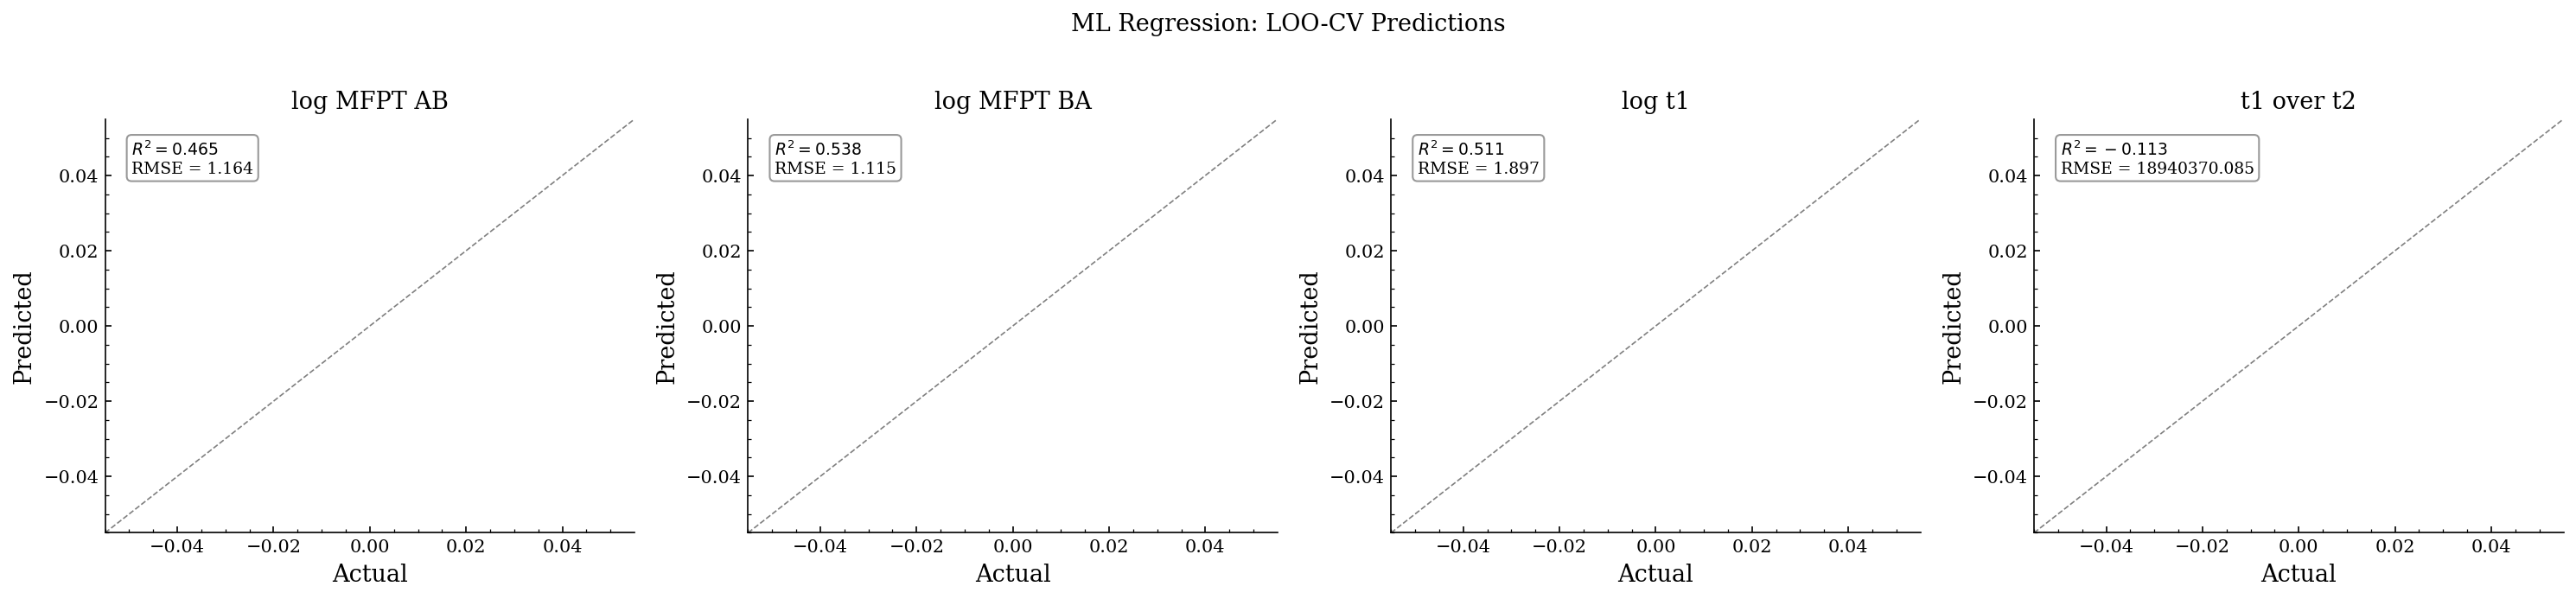

In [27]:
# ── Predicted vs Actual scatter (best model per target) ────────
if ml_dir.exists():
    pred_files = sorted(ml_dir.glob("predictions_*.csv"))
    if pred_files:
        n = len(pred_files)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5))
        if n == 1: axes = [axes]
        for ax, pf in zip(axes, pred_files):
            pdf = pd.read_csv(pf)
            target_name = pf.stem.replace("predictions_", "")
            pdf_m = pdf.merge(gt[["dps_dir", "seq", "colour"]], on="dps_dir", how="left")

            ax.scatter(pdf_m["actual"], pdf_m["predicted"],
                       c=pdf_m.get("colour", DARK), s=35, alpha=0.8,
                       edgecolors="white", linewidths=0.4)
            # annotate sequences
            for _, row in pdf_m.iterrows():
                if "seq" in row:
                    ax.annotate(row["seq"], (row["actual"], row["predicted"]),
                                fontsize=5, alpha=0.5, ha="center", va="bottom",
                                xytext=(0, 3), textcoords="offset points")
            parity_line(ax)
            annotate_r2(ax, pdf_m["actual"].values, pdf_m["predicted"].values)
            ax.set_xlabel("Actual")
            ax.set_ylabel("Predicted")
            ax.set_title(target_name.replace("_", " "))
        fig.suptitle("ML Regression: LOO-CV Predictions", fontsize=13, y=1.02)
        fig.tight_layout()
        fig.savefig("fig_ml_predictions.pdf")
        plt.show()
    else:
        print("No prediction CSVs found in ml_results_cpu/.")

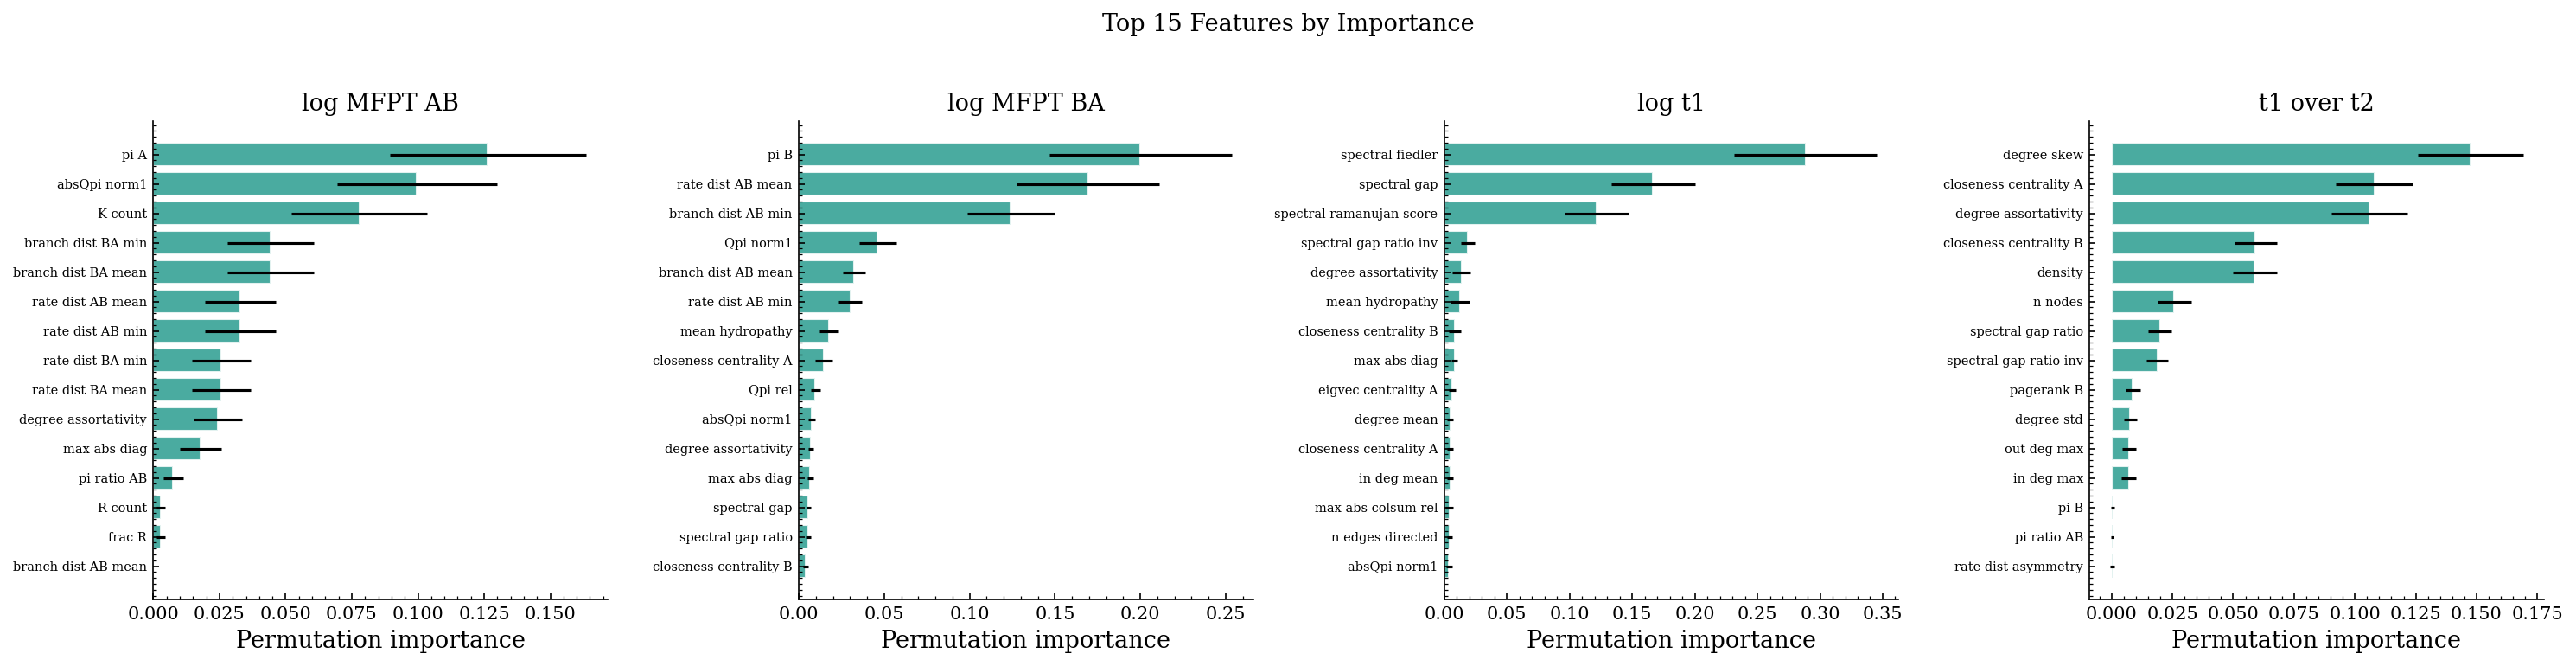

In [28]:
# ── Feature importance (permutation) ─────────────────────────────
if ml_dir.exists():
    imp_files = sorted(ml_dir.glob("feature_importance_*.csv"))
    if imp_files:
        n = len(imp_files)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
        if n == 1: axes = [axes]
        for ax, imp_f in zip(axes, imp_files):
            imp = pd.read_csv(imp_f).sort_values("importance", ascending=True).tail(15)
            ax.barh(range(len(imp)), imp["importance"],
                    xerr=imp.get("importance_std", None),
                    color=TEAL, alpha=0.85, edgecolor="white")
            ax.set_yticks(range(len(imp)))
            ax.set_yticklabels(imp["feature"].str.replace("_", " "), fontsize=7)
            ax.set_xlabel("Permutation importance")
            target_name = imp_f.stem.replace("feature_importance_", "")
            ax.set_title(target_name.replace("_", " "))
        fig.suptitle("Top 15 Features by Importance", fontsize=13, y=1.02)
        fig.tight_layout()
        fig.savefig("fig_feature_importance.pdf")
        plt.show()
    else:
        print("No feature importance CSVs found in ml_results_cpu/.")

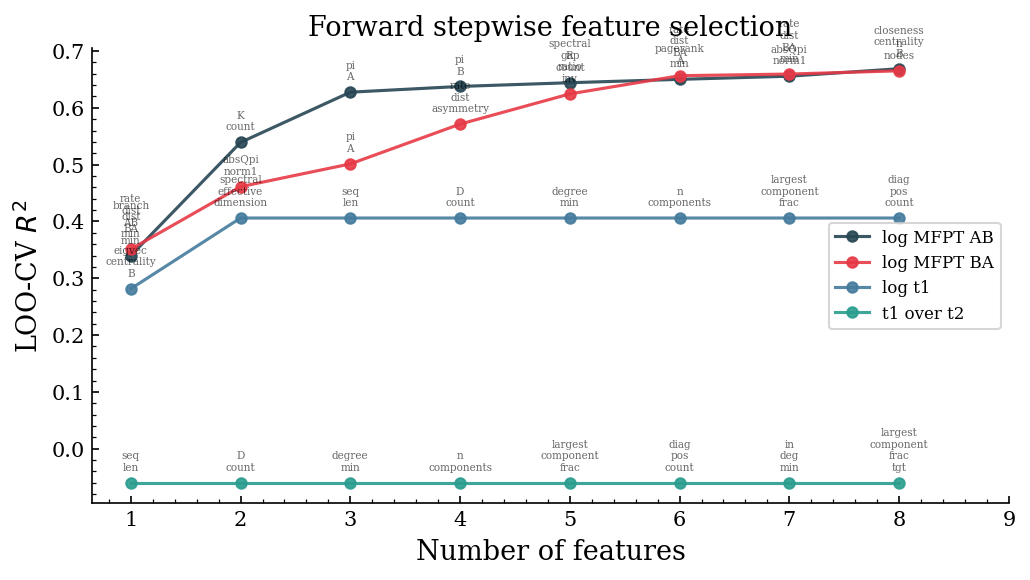

In [29]:
# ── Forward selection curve ──────────────────────────────────────
if ml_dir.exists():
    sel_files = sorted(ml_dir.glob("forward_selection_*.csv"))
    if sel_files:
        fig, ax = plt.subplots(figsize=(7, 4))
        for i, sf in enumerate(sel_files):
            sel = pd.read_csv(sf)
            target_name = sf.stem.replace("forward_selection_", "")
            ax.plot(range(1, len(sel)+1), sel["R2"],
                    "o-", color=PALETTE[i % len(PALETTE)], markersize=5,
                    label=target_name.replace("_", " "), alpha=0.9)
            # annotate feature names
            for j, row in sel.iterrows():
                ax.annotate(row["feature"].replace("_", "\n"),
                            (j+1, row["R2"]), fontsize=5, alpha=0.6,
                            ha="center", va="bottom",
                            xytext=(0, 5), textcoords="offset points")
        ax.set_xlabel("Number of features")
        ax.set_ylabel("LOO-CV $R^2$")
        ax.set_title("Forward stepwise feature selection")
        ax.legend(fontsize=8)
        ax.set_xticks(range(1, 10))
        fig.tight_layout()
        fig.savefig("fig_forward_selection.pdf")
        plt.show()
    else:
        print("No forward selection CSVs found in ml_results_cpu/.")

---
## 8. GNN Results

Requires output from `train_gnn.py` in `gnn_results_cpu/`.

In [30]:
if gnn_dir.exists():
    # ── Per-configuration metrics (from train_gnn_v2.py) ─────────
    metrics_files = sorted(gnn_dir.glob("metrics_*.json"))
    if metrics_files:
        print("=== GNN Model Metrics ===")
        for mf in metrics_files:
            with open(mf) as f:
                m = json.load(f)
            config = mf.stem.replace("metrics_", "")
            print(f"\n  [{config}]")
            for k, v in m.items():
                if isinstance(v, float):
                    print(f"    {k}: {v:.4f}")
                else:
                    print(f"    {k}: {v}")
    else:
        print("No metrics_*.json files found.")

    # ── Comparison summary ───────────────────────────────────────
    comp_path = gnn_dir / "comparison_summary.json"
    if comp_path.exists():
        with open(comp_path) as f:
            gnn_comparison = json.load(f)
        gnn_comp_df = pd.DataFrame(gnn_comparison)
        print("\n=== GNN Comparison Summary ===")
        display(gnn_comp_df.style.format(precision=4))
    else:
        print("No comparison_summary.json found.")

    # ── Results plots (already saved as PNG by train_gnn_v2.py) ──
    result_pngs = sorted(gnn_dir.glob("results_*.png"))
    if result_pngs:
        n = len(result_pngs)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5))
        if n == 1: axes = [axes]
        for ax, rpng in zip(axes, result_pngs):
            img = plt.imread(str(rpng))
            ax.imshow(img)
            ax.set_axis_off()
            config = rpng.stem.replace("results_", "")
            ax.set_title(config.replace("_", " "), fontsize=10)
        fig.suptitle("GNN Training Results", fontsize=13, y=1.02)
        fig.tight_layout()
        plt.show()
    else:
        print("No results_*.png files found.")
else:
    print("gnn_results_v2/ not found. Run: sbatch run_gnn_v2.sbatch")


No node_metrics_*.json files found.
No graph_loocv_*_preds.npz files found.


---
## 9. ML vs GNN Comparison

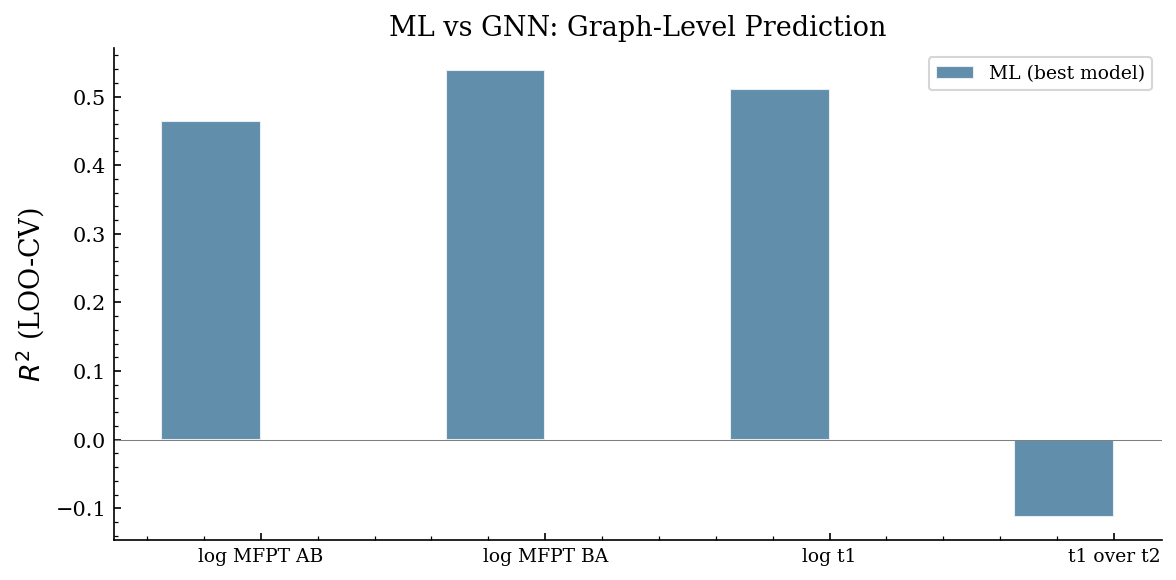

method,ML (best)
target,
log_MFPT_AB,0.4648
log_MFPT_BA,0.5381
log_t1,0.5112
t1_over_t2,-0.1132


In [31]:
# Compare ML and GNN R² on graph-level targets
comparison = []

# ML R² values
if ml_dir.exists():
    for pf in sorted(ml_dir.glob("predictions_*.csv")):
        pdf = pd.read_csv(pf)
        target = pf.stem.replace("predictions_", "")
        r2 = 1 - np.sum((pdf["actual"] - pdf["predicted"])**2) / \
                 np.sum((pdf["actual"] - pdf["actual"].mean())**2)
        comparison.append({"target": target, "method": "ML (best)", "R2": r2})

# GNN R² values (from metrics JSON files)
if gnn_dir.exists():
    comp_path = gnn_dir / "comparison_summary.json"
    if comp_path.exists():
        with open(comp_path) as f:
            gnn_results = json.load(f)
        # Pick the best R² across configs for each task
        best_by_task = {}
        for entry in gnn_results:
            task = entry.get("task", entry.get("config", "unknown"))
            r2 = entry.get("val_r2", float("nan"))
            if task not in best_by_task or r2 > best_by_task[task]:
                best_by_task[task] = r2
        for task, r2 in best_by_task.items():
            comparison.append({"target": task, "method": "GNN (best)", "R2": r2})
    else:
        for mf in sorted(gnn_dir.glob("metrics_*.json")):
            with open(mf) as f:
                m = json.load(f)
            config = mf.stem.replace("metrics_", "")
            comparison.append({"target": m.get("task", config),
                               "method": "GNN", "R2": m.get("val_r2", float("nan"))})

if comparison:
    comp_df = pd.DataFrame(comparison)
    pivot = comp_df.pivot(index="target", columns="method", values="R2")

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pivot))
    width = 0.35
    if "ML (best)" in pivot.columns:
        ax.bar(x - width/2, pivot["ML (best)"], width, color=BLUE,
               alpha=0.85, label="ML (best model)", edgecolor="white")
    if "GNN (best)" in pivot.columns:
        ax.bar(x + width/2, pivot["GNN (best)"], width, color=ACCENT,
               alpha=0.85, label="GNN (best)", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index.str.replace("_", " "), fontsize=9)
    ax.set_ylabel("$R^2$ (LOO-CV)")
    ax.set_title("ML vs GNN: Graph-Level Prediction")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    fig.tight_layout()
    fig.savefig("fig_ml_vs_gnn.pdf")
    plt.show()
    display(pivot.style.format(precision=4).background_gradient(cmap="RdYlGn", vmin=-1, vmax=1))
else:
    print("No ML or GNN results available yet for comparison.")


---
## 10. Summary Statistics

In [32]:
# Summary table for thesis
summary_cols = ["seq", "N_micro", "N_coarse", "compression"]
if "MFPT_coarse_AB" in gt.columns:
    summary_cols.append("MFPT_coarse_AB")
if "MFPT_coarse_BA" in gt.columns:
    summary_cols.append("MFPT_coarse_BA")
if "t1" in gt.columns:
    summary_cols.append("t1")
if "t1" in gt.columns and "t2" in gt.columns:
    gt["t1_t2_ratio"] = gt["t1"] / gt["t2"]
    summary_cols.append("t1_t2_ratio")

summary = gt[summary_cols].copy()
summary["compression"] = (summary["compression"] * 100).round(1)
summary = summary.rename(columns={"compression": "compression_pct"})

print("=== Summary Statistics ===")
display(summary.describe().round(3))

# LaTeX export
latex_str = summary.to_latex(index=False, float_format="%.3g",
                             caption="Summary of coarse-grained KTN properties at T=300K.",
                             label="tab:ktn_summary")
with open("table_ktn_summary.tex", "w") as f:
    f.write(latex_str)
print("\nLaTeX table saved to table_ktn_summary.tex")

=== Summary Statistics ===


,N_micro,N_coarse,compression_pct,MFPT_coarse_AB,MFPT_coarse_BA,t1,t1_t2_ratio
count,37.000,36.000,36.000,36.0,36.0,3.600000e+01,3.600000e+01
mean,41217.622,4002.222,90.331,0.0,0.0,3.008744e+06,3.285139e+06
std,22849.685,2236.841,0.098,0.0,0.0,1.606204e+07,1.796040e+07
min,2821.000,276.000,90.100,0.0,0.0,0.000000e+00,1.182000e+00
25%,30309.000,2921.250,90.300,0.0,0.0,1.583467e+04,4.786000e+00
50%,35345.000,3651.500,90.300,0.0,0.0,5.272602e+04,2.345780e+02
75%,50219.000,4888.250,90.400,0.0,0.0,9.877571e+04,3.366960e+03
max,119078.000,11588.000,90.500,0.0,0.0,9.638434e+07,1.077537e+08



LaTeX table saved to table_ktn_summary.tex


---
## 11. Teleodynamic Interpretation

Verdict figure: Does graph structure predict kinetic fate?

<__array_function__ internals>:5: UserWarning: Warning: converting a masked element to nan.
/usr/licensed/anaconda3/2021.11/lib/python3.9/site-packages/numpy/core/_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


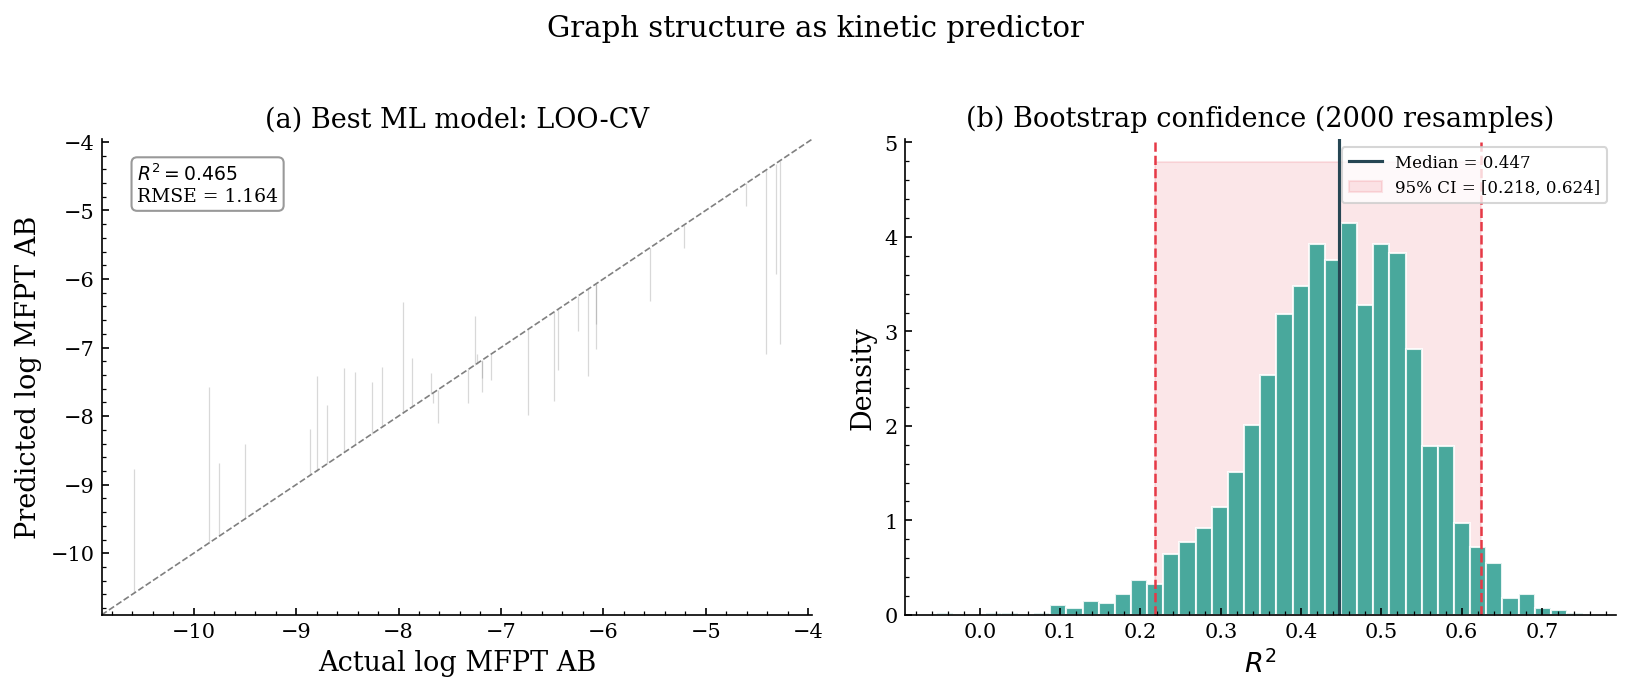


Verdict: Bootstrap R² = 0.447 [0.218, 0.624] (95% CI)


In [33]:
# Bootstrap confidence bands for best ML model
if ml_dir.exists():
    pred_files = sorted(ml_dir.glob("predictions_*.csv"))
    if pred_files:
        # Use first target
        pdf = pd.read_csv(pred_files[0])
        target_name = pred_files[0].stem.replace("predictions_", "")

        actual = pdf["actual"].values
        predicted = pdf["predicted"].values

        # Bootstrap R²
        n_boot = 2000
        rng = np.random.default_rng(42)
        boot_r2 = []
        for _ in range(n_boot):
            idx = rng.choice(len(actual), size=len(actual), replace=True)
            ss_res = np.sum((actual[idx] - predicted[idx])**2)
            ss_tot = np.sum((actual[idx] - actual[idx].mean())**2)
            boot_r2.append(1 - ss_res / ss_tot if ss_tot > 0 else 0)
        boot_r2 = np.array(boot_r2)

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

        # (a) Predicted vs actual with residual error bars
        ax = axes[0]
        residuals = actual - predicted
        pdf_m = pdf.merge(gt[["dps_dir", "seq", "colour"]], on="dps_dir", how="left")
        ax.scatter(actual, predicted,
                   c=pdf_m.get("colour", DARK), s=40, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)
        # error bars (residuals)
        ax.vlines(actual, predicted, actual, color="gray", alpha=0.3, lw=0.6, zorder=1)
        parity_line(ax)
        annotate_r2(ax, actual, predicted)
        ax.set_xlabel(f"Actual {target_name.replace('_', ' ')}")
        ax.set_ylabel(f"Predicted {target_name.replace('_', ' ')}")
        ax.set_title("(a) Best ML model: LOO-CV")

        # (b) Bootstrap R² distribution
        ax = axes[1]
        ax.hist(boot_r2, bins=40, color=TEAL, edgecolor="white", alpha=0.85, density=True)
        ci_lo, ci_hi = np.percentile(boot_r2, [2.5, 97.5])
        ax.axvline(ci_lo, color=ACCENT, ls="--", lw=1.2)
        ax.axvline(ci_hi, color=ACCENT, ls="--", lw=1.2)
        ax.axvline(np.median(boot_r2), color=DARK, ls="-", lw=1.5,
                   label=f"Median = {np.median(boot_r2):.3f}")
        ax.fill_betweenx([0, ax.get_ylim()[1]*1.1], ci_lo, ci_hi,
                         color=ACCENT, alpha=0.12,
                         label=f"95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]")
        ax.set_xlabel("$R^2$")
        ax.set_ylabel("Density")
        ax.set_title("(b) Bootstrap confidence (2000 resamples)")
        ax.legend(fontsize=8)

        fig.suptitle("Graph structure as kinetic predictor", fontsize=14, y=1.02)
        fig.tight_layout()
        fig.savefig("fig_teleodynamic_verdict.pdf")
        plt.show()

        print(f"\nVerdict: Bootstrap R² = {np.median(boot_r2):.3f} "
              f"[{ci_lo:.3f}, {ci_hi:.3f}] (95% CI)")
    else:
        print("No ML predictions available for verdict figure.")
else:
    print("ml_results_cpu/ not found — run ML regression first.")

---

**Figures saved as PDF:**
- `fig_landscape_overview.pdf`
- `fig_kinetic_observables.pdf`
- `fig_spectral_fingerprints.pdf`
- `fig_network_topology.pdf`
- `fig_feature_correlations.pdf`
- `fig_top_features.pdf`
- `fig_ml_predictions.pdf`
- `fig_feature_importance.pdf`
- `fig_forward_selection.pdf`
- `fig_gnn_predictions.pdf`
- `fig_ml_vs_gnn.pdf`
- `fig_teleodynamic_verdict.pdf`
- `table_ktn_summary.tex`